# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Rodrigo Hernández

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del domingo 20 de septiembre (hora de Argentina)**.

La resolución del TP puede realizarse de forma **individual, en parejas o hasta en grupos de 3 como máximo**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que todos los integrantes deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local (posteriormente deben subirlo a Google Drive). Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/HRfmzTPcM1yyMWw86)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERAPELLIDOALUMNO3-TP1-Co26.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co26.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros que se busca optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado), acotada de -1 a 1 en el eje vertical. Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

#### Respuesta 1.a

El modelo es una única conexión sináptica con activación tangente hiperbólica:

$$z_i = w\,x_i + b \qquad\Longrightarrow\qquad \hat y_i = \tanh(z_i) = \tanh(w\,x_i + b)$$

Hay solamente dos parámetros, $w$ y $b$. Eso tiene dos consecuencias:

1. El espacio de parámetros es un plano $(w,b)$ y el costo $J(w,b)$ es una superficie sobre ese plano, así que todo el entrenamiento se puede pensar como un punto bajando por esa superficie.
2. Como $\tanh$ es monótona y acotada en $(-1,1)$, el modelo solo puede representar una única curva en forma de S: $w$ controla su pendiente y su signo, y $b$ la desplaza horizontalmente (el centro de la S cae en $x = -b/w$). No puede generar jorobas ni oscilaciones, así que el dataset tiene que ser algo que una S pueda aproximar.

Para facilitar mi entendimiento, le doy interpretación al dataset: la curva de respuesta del acelerador de un auto.

| Variable | Interpretación |
|---|---|
| $x \in [-3, 3]$ | Posición del pedal: $-3$ = freno a fondo, $0$ = ningún pedal, $+3$ = acelerador a fondo |
| $y \in [-1, 1]$ | Aceleración resultante, normalizada al máximo que da el auto |
| $n = 300$ | Cantidad de mediciones del ensayo |
| ruido $\sigma = 0.06$ | Pendiente de la calle, viento, peso de los pasajeros, error de medición |
| $w$ | Qué tan reactivo es el auto (deportivo vs. camioneta cargada) |
| $b$ | Cuánto avanza el auto solo, con el pie afuera del pedal |

Bajo esta lectura, entrenar la red equivale a caracterizar el auto.

El patrón no lineal elegido es:

$$f(x) = 0.5\,\tanh(2x) \;+\; 0.4\,\sin(0.5x)$$

Tres criterios para esta elección:

- Está acotado en $[-1,1]$. Físicamente corresponde al techo del auto: por más que pises, el motor da lo que da.
- No es una `tanh` sola. El término $0.4\sin(0.5x)$ representa una compresión suave de la respuesta, donde la aceleración sigue trepando lentamente hacia el techo en lugar de recortarse de golpe.
- Es estrictamente creciente en $[-3,3]$, ya que $f'(x) = \left(1-\tanh^2(2x)\right) + 0.2\cos(0.5x) > 0$ en todo el intervalo (el mínimo es $0.0142$). Ningún auto acelera menos cuando pisás más.

x : 300 puntos en [-3.0, 3.0]
y : rango [-1.015, 1.008]   (acotado en [-1, 1])
Piso de error irreducible por ruido: sigma^2 = 0.00360


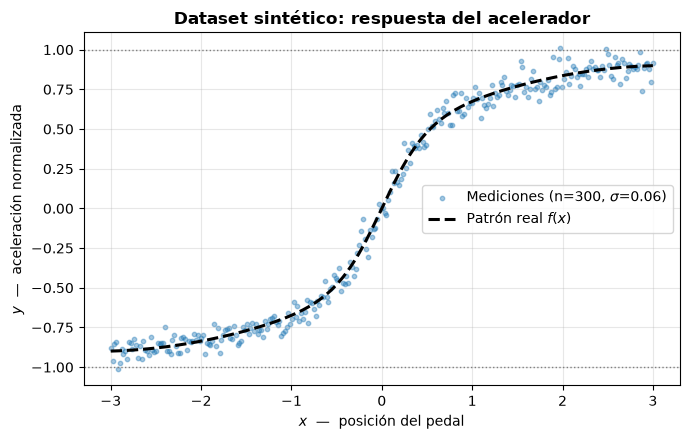

In [29]:
import time
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# DATASET SINTÉTICO
# ----------------------------------------------------------------------
N     = 300    # cantidad de muestras
SIGMA = 0.06   # desvío del ruido de medición

# Barrido del pedal: 300 posiciones equiespaciadas, de freno a fondo a acelerador a fondo
x = np.linspace(-3, 3, N)

def patron_no_lineal(x):
    """Curva 'real' del auto: techo de aceleración (tanh) + compresión suave (sin)."""
    return 0.5 * np.tanh(2 * x) + 0.4 * np.sin(0.5 * x)

# Generador propio para el ruido, con semilla fija -> el dataset es siempre el mismo.
# Se usa un generador separado del de la inicialización de parámetros para que ambas
# cosas sean reproducibles de forma independiente.
rng_datos = np.random.default_rng(42)
y = patron_no_lineal(x) + rng_datos.normal(0, SIGMA, N)

print(f"x : {N} puntos en [{x.min():.1f}, {x.max():.1f}]")
print(f"y : rango [{y.min():.3f}, {y.max():.3f}]   (acotado en [-1, 1])")
print(f"Piso de error irreducible por ruido: sigma^2 = {SIGMA**2:.5f}")

plt.figure(figsize=(7, 4.5))
plt.scatter(x, y, s=10, alpha=0.4, label=f"Mediciones (n={N}, $\\sigma$={SIGMA})")
plt.plot(x, patron_no_lineal(x), "k--", lw=2.2, label="Patrón real $f(x)$")
plt.axhline( 1, color="gray", ls=":", lw=1)
plt.axhline(-1, color="gray", ls=":", lw=1)
plt.xlabel("$x$  —  posición del pedal")
plt.ylabel("$y$  —  aceleración normalizada")
plt.title("Dataset sintético: respuesta del acelerador", fontweight="bold")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Derivación del gradiente

La cadena completa es:

$$J \;\longleftarrow\; \hat y \;\longleftarrow\; z \;\longleftarrow\; (w,\,b)$$

Derivando eslabón por eslabón:

$$\frac{\partial J}{\partial \hat y_i} = \frac{2}{m}\left(\hat y_i - y_i\right)
\qquad
\underbrace{\frac{\partial \hat y_i}{\partial z_i} = 1 - \tanh^2(z_i) = 1 - \hat y_i^{\,2}}_{\text{eslabón nuevo}}
\qquad
\frac{\partial z_i}{\partial w} = x_i
\qquad
\frac{\partial z_i}{\partial b} = 1$$

Multiplicando la cadena y sumando sobre las $m$ muestras:

$$\boxed{\;\frac{\partial J}{\partial w} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat y_i - y_i\right)\left(1 - \hat y_i^{\,2}\right)x_i
\qquad
\frac{\partial J}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat y_i - y_i\right)\left(1 - \hat y_i^{\,2}\right)\;}$$

Es idéntico al gradiente del modelo lineal salvo el factor $\left(1 - \hat y_i^{\,2}\right)$, que funciona como una válvula sobre la señal de error:

- Cuando $\hat y_i \approx 0$ el factor vale $\approx 1$, multiplica por uno y no atenúa nada: el gradiente que le llega a $w$ y $b$ es el mismo que tendría un modelo lineal sin activación.
- Cuando $\hat y_i \to \pm 1$ el factor vale $\approx 0$ y divide la señal por un número grande. La neurona está saturada y la corrección se apaga sin importar cuán grande sea el error.

A lo segundo se le llama *vanishing gradient*: el gradiente se vuelve tan chico que los parámetros dejan de moverse, y no porque el algoritmo haya llegado al mínimo sino porque la señal que le indica hacia dónde ir se atenuó en el camino. Son dos situaciones opuestas que desde afuera se ven iguales.

En el punto donde arranca este experimento las 300 predicciones caen entre $0.960$ y $0.985$, todas pegadas al techo, y el factor promedia $0.0506$. El gradiente termina valiendo $0.206$ cuando sin la saturación valdría $3.095$: una atenuación de 15 veces. El error es enorme y la señal cruda también, pero casi nada de eso llega a los parámetros.

Acá el efecto aparece con una sola capa y un único factor. El nombre viene de las redes profundas, donde estos factores se multiplican capa por capa: $0.05$ elevado a diez capas da $10^{-13}$ y el gradiente desaparece del todo.

Esto es lo que hace que $J(w,b)$ sea no convexa: aparecen mesetas planas donde el costo es altísimo pero el gradiente es casi nulo. En la interpretación del auto: si el modelo cree que el auto satura con cualquier toque del pedal, predice "a fondo" para las 300 mediciones, y cambiar un poco $w$ no modifica ninguna predicción. Las mediciones dejan de informar en qué dirección corregirse.

Nota de implementación: como $\hat y = \tanh(z)$, el factor $1-\hat y^2$ se calcula reutilizando el resultado del forward pass, sin recomputar nada. (_backpropagation: guardar las activaciones de la ida para usarlas en la vuelta_)

In [30]:
# ----------------------------------------------------------------------
# FUNCIÓN DE COSTO Y GRADIENTE
# ----------------------------------------------------------------------

def costo(w, b):
    """J(w,b) = (1/m) * sum( (y_hat - y)^2 )   con y_hat = tanh(w*x + b)"""
    y_hat = np.tanh(w * x + b)
    return np.mean((y_hat - y) ** 2)


def gradiente(w, b):
    """Versión vectorizada. Traduce literalmente las fórmulas derivadas arriba."""
    y_hat = np.tanh(w * x + b)                     # forward pass
    delta = (2 / N) * (y_hat - y) * (1 - y_hat**2) # (2/m)·(y_hat - y)·(1 - y_hat²)
    dJ_dw = np.sum(delta * x)                      #   ... · x_i
    dJ_db = np.sum(delta)                          #   ... · 1
    return dJ_dw, dJ_db


def gradiente_con_for(w, b):
    """Misma fórmula, sumando muestra por muestra. Solo para verificar la vectorizada."""
    dJ_dw = 0.0
    dJ_db = 0.0
    for i in range(N):
        y_hat_i = np.tanh(w * x[i] + b)
        delta_i = (2 / N) * (y_hat_i - y[i]) * (1 - y_hat_i**2)
        dJ_dw += delta_i * x[i]
        dJ_db += delta_i
    return dJ_dw, dJ_db


# --- Verificación: ambas implementaciones deben coincidir ---
w_test, b_test = 0.5, -0.3
g_vec = gradiente(w_test, b_test)
g_for = gradiente_con_for(w_test, b_test)

assert np.allclose(g_vec, g_for), "Las dos implementaciones del gradiente no coinciden"

print(f"Gradiente en (w={w_test}, b={b_test}):")
print(f"  con bucle explícito : dJ/dw = {g_for[0]:+.10f}   dJ/db = {g_for[1]:+.10f}")
print(f"  vectorizado         : dJ/dw = {g_vec[0]:+.10f}   dJ/db = {g_vec[1]:+.10f}")
print("  assert OK -> mismo resultado\n")

# --- Por qué se usa la vectorizada de acá en adelante ---
t0 = time.perf_counter(); [gradiente(w_test, b_test)         for _ in range(200)]; t_vec = time.perf_counter() - t0
t0 = time.perf_counter(); [gradiente_con_for(w_test, b_test) for _ in range(200)]; t_for = time.perf_counter() - t0
print(f"200 evaluaciones: vectorizado {t_vec*1e3:6.1f} ms | con bucle {t_for*1e3:6.1f} ms  ->  {t_for/t_vec:.0f}x más rápido")

Gradiente en (w=0.5, b=-0.3):
  con bucle explícito : dJ/dw = -0.2654244554   dJ/db = -0.2945783155
  vectorizado         : dJ/dw = -0.2654244554   dJ/db = -0.2945783155
  assert OK -> mismo resultado

200 evaluaciones: vectorizado    1.1 ms | con bucle   29.1 ms  ->  26x más rápido


#### Full-batch y la inicialización

Un *batch* es el conjunto de muestras con el que se calcula una actualización de los parámetros. Acá el gradiente se calcula siempre con las 300 muestras del dataset, que es lo que se llama *full-batch*: cada época produce exactamente una actualización, así que 100 épocas son 100 actualizaciones. La ventaja es que ese gradiente es el gradiente exacto de $J$, sin aproximación, y la trayectoria sale suave y determinista. La desventaja es la cantidad de actualizaciones: recorrer las 300 muestras enteras para dar un solo paso.

Sobre la inicialización, $w$ y $b$ se generan con `np.random.randn()` una sola vez, con semilla fija, y quedan guardados en `W0` y `B0` para que los tres learning rates arranquen exactamente del mismo punto. Si cada corrida empezara en otro lado las curvas no serían comparables y el experimento no mediría el efecto del learning rate.

Vale aclarar qué hace la semilla, porque no quita que los valores sean aleatorios. `np.random.randn()` es un generador pseudoaleatorio: produce números a partir de un estado interno siguiendo un algoritmo determinista. `np.random.seed(18)` fija ese estado, de modo que la secuencia que sale es siempre la misma en cualquier máquina. Los valores siguen siendo una muestra legítima de una $\mathcal{N}(0,1)$, no están escritos a mano; lo único que queda fijado es cuál de todas las secuencias posibles toca. Sin semilla, cada ejecución del notebook daría parámetros iniciales distintos y el análisis escrito más abajo no coincidiría con los números que se obtienen al correrlo.

Elegir qué semilla usar sí es una decisión mía y prefiero dejarla a la vista. La celda siguiente imprime el punto de arranque de cuatro semillas. Con las semillas 0, 7 y 42 el costo inicial ya está entre 0.03 y 0.06, o sea que el modelo arranca prácticamente resuelto y los tres learning rates terminan dando curvas parecidas entre sí. La semilla 18 arranca con costo 1.47 y gradiente 0.21, que es una meseta de saturación: un punto de partida poco frecuente pero perfectamente alcanzable por `randn()`, y el único de los cuatro donde el learning rate cambia el resultado de manera visible.

In [31]:
# ----------------------------------------------------------------------
# ALGORITMO DEL GRADIENTE DESCENDENTE (GD)
# ----------------------------------------------------------------------
EPOCAS = 100
LRS    = [0.1, 0.01, 0.001]

def entrenar_gd(w0, b0, lr, epocas=EPOCAS):
    """
    GD full-batch. Devuelve el historial completo de (w, b, J).

    Se guardan también w y b, no solo el costo, para poder reconstruir después
    la trayectoria que recorre el algoritmo en el espacio de parámetros.

    Convención: el historial arranca con el punto inicial (época 0) y agrega
    un valor por cada actualización, de modo que len(historial) = epocas + 1.
    """
    w, b = w0, b0
    hist_w, hist_b, hist_J = [w], [b], [costo(w, b)]

    for _ in range(epocas):                 # <-- el bucle de épocas: el proceso iterativo
        dJ_dw, dJ_db = gradiente(w, b)      # 1. gradiente con TODO el dataset (full-batch)
        w = w - lr * dJ_dw                  # 2. actualización del peso
        b = b - lr * dJ_db                  # 3. actualización del bias
        hist_w.append(w); hist_b.append(b); hist_J.append(costo(w, b))

    return np.array(hist_w), np.array(hist_b), np.array(hist_J)


# --- Por qué esta semilla: punto de arranque de varias semillas ---
print("Punto de arranque según la semilla:")
for s in (0, 7, 18, 42):
    np.random.seed(s)
    w_s, b_s = np.random.randn(), np.random.randn()
    print(f"  seed={s:>3}:  w0={w_s:+.4f}  b0={b_s:+.4f}   J={costo(w_s, b_s):.4f}   ||grad||={np.hypot(*gradiente(w_s, b_s)):.4f}")
print()

# --- Inicialización: una sola vez, la misma para los tres learning rates ---
np.random.seed(18)
W0 = np.random.randn()
B0 = np.random.randn()

norma_grad_inicial = np.hypot(*gradiente(W0, B0))
print(f"Inicialización:  w0 = {W0:.4f}   b0 = {B0:.4f}")
print(f"  J(w0, b0)      = {costo(W0, B0):.4f}   <- costo alto")
print(f"  ||grad(w0,b0)||= {norma_grad_inicial:.4f}   <- gradiente casi nulo: meseta de saturación\n")

# --- Entrenamiento con los 3 learning rates, desde el MISMO punto inicial ---
hist_gd = {lr: entrenar_gd(W0, B0, lr) for lr in LRS}

print(f"{'lr':>7} | {'J inicial':>10} | {'J final':>10} | {'reducción':>10} | {'w final':>8} | {'b final':>8}")
print("-" * 70)
for lr in LRS:
    h_w, h_b, h_J = hist_gd[lr]
    print(f"{lr:>7} | {h_J[0]:>10.5f} | {h_J[-1]:>10.5f} | {100*(1-h_J[-1]/h_J[0]):>9.1f}% | {h_w[-1]:>8.4f} | {h_b[-1]:>8.4f}")

Punto de arranque según la semilla:
  seed=  0:  w0=+1.7641  b0=+0.4002   J=0.0530   ||grad||=0.0725
  seed=  7:  w0=+1.6905  b0=-0.4659   J=0.0560   ||grad||=0.0855
  seed= 18:  w0=+0.0794  b0=+2.1902   J=1.4750   ||grad||=0.2061
  seed= 42:  w0=+0.4967  b0=-0.1383   J=0.0346   ||grad||=0.2330

Inicialización:  w0 = 0.0794   b0 = 2.1902
  J(w0, b0)      = 1.4750   <- costo alto
  ||grad(w0,b0)||= 0.2061   <- gradiente casi nulo: meseta de saturación

     lr |  J inicial |    J final |  reducción |  w final |  b final
----------------------------------------------------------------------
    0.1 |    1.47500 |    0.03899 |      97.4% |   1.5156 |   0.2707
   0.01 |    1.47500 |    1.21768 |      17.4% |   0.4679 |   1.9693
  0.001 |    1.47500 |    1.47035 |       0.3% |   0.0972 |   2.1780


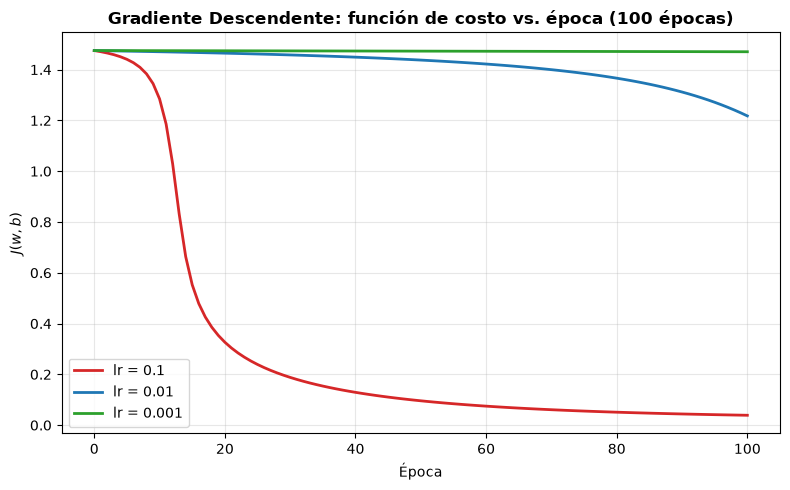

In [32]:
# ----------------------------------------------------------------------
# GRÁFICA: J(w,b) vs ÉPOCA, los 3 learning rates superpuestos
# ----------------------------------------------------------------------
COLORES = {0.1: "tab:red", 0.01: "tab:blue", 0.001: "tab:green"}

plt.figure(figsize=(8, 5))
for lr in LRS:
    plt.plot(hist_gd[lr][2], color=COLORES[lr], lw=2, label=f"lr = {lr}")

plt.xlabel("Época")
plt.ylabel("$J(w,b)$")
plt.title("Gradiente Descendente: función de costo vs. época (100 épocas)", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Análisis de los resultados

| $lr$ | $J$ inicial | $J$ final | Reducción | $w$ final | $b$ final |
|---|---|---|---|---|---|
| 0.1 | 1.4750 | 0.0390 | 97.4 % | 1.5156 | 0.2707 |
| 0.01 | 1.4750 | 1.2177 | 17.4 % | 0.4679 | 1.9693 |
| 0.001 | 1.4750 | 1.4704 | 0.3 % | 0.0972 | 2.1780 |

De los tres learning rates probados, 0.1 es claramente el mejor: es el único que consigue que el modelo aprenda algo dentro de las 100 épocas. Con 0.01 el entrenamiento queda a mitad de camino y con 0.001 directamente no arranca. El resto del análisis es sobre por qué la diferencia entre ellos es tan grande.

Lo que más me llamó la atención es la forma de la curva de $lr=0.1$. No baja como una exponencial, que es lo que uno esperaría en un problema convexo: tiene tres tramos bien distintos. Durante las primeras 8 épocas el costo casi no se mueve, entre las épocas 10 y 20 se desploma, y después entra en una cola lenta. Cada tramo se explica con la superficie que describí arriba:

- El tramo plano inicial es la meseta de saturación. Arranca con $\|\nabla J\| = 0.206$, y como el paso que da GD es $lr \cdot \|\nabla J\|$, el desplazamiento por época es de apenas $0.02$ aunque el learning rate sea el más grande de los tres.
- La caída abrupta aparece cuando $b$ baja lo suficiente como para sacar a la neurona de la saturación. El factor $(1-\hat y^2)$ se despierta, el gradiente crece un orden de magnitud y el descenso se acelera solo, sin que yo haya tocado ningún hiperparámetro.
- La cola lenta es el gradiente volviéndose chico otra vez cerca del mínimo. A la época 100 la curva todavía baja, así que ni siquiera el mejor de los tres learning rates terminó de converger en el presupuesto de épocas disponible.

El caso de $lr=0.001$ conviene mirarlo por los parámetros y no por el costo. Terminó en $w = 0.097$ y $b = 2.178$, o sea que el modelo predice $\tanh(0.097x + 2.178) \approx 0.975$ para cualquier $x$: una recta horizontal pegada al techo. Traducido a la historia del auto, el modelo afirma que el vehículo acelera a fondo siempre, se pise el freno o el acelerador. Después de 100 épocas no aprendió nada sobre la relación entre pedal y aceleración, y no es que tarde más en llegar: no se movió del lugar donde arrancó.

Eso lleva a lo que me parece la conclusión más interesante del punto: la diferencia entre los tres learning rates no es proporcional a los learning rates. El paso real es el learning rate multiplicado por la magnitud del gradiente, y en una meseta ese segundo factor ya es chico de por sí, así que los dos efectos se multiplican en lugar de compensarse. Con $lr=0.001$ el desplazamiento es de unas $2\times10^{-4}$ unidades por época, y en 100 épocas el punto recorre $0.02$ en el espacio de parámetros.

También queda expuesta una limitación de fondo del GD: no tiene forma de distinguir una meseta de un mínimo. En los dos casos el gradiente es chico y en los dos casos da pasos chicos, cuando en realidad son situaciones opuestas. Le falta información para saber si el gradiente es chico porque llegó o porque la neurona está saturada.

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno full-batch y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.